# Task 1
Using sudoku.png because one side of it is clearly darker than the other.

Trying 3 global thresholds: 80, 127 and 180. Picked a low, a middle and a high
value so I can see it fail in both directions.

For adaptive I used Gaussian with blockSize 11 and C 2 (the usual starting values).

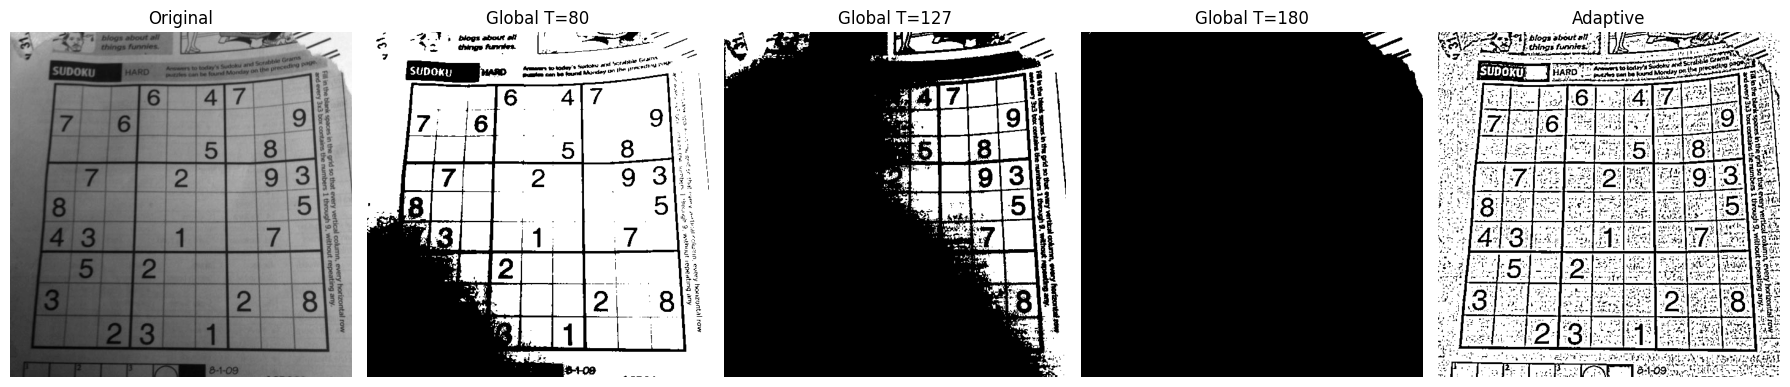

In [2]:
import cv2
import matplotlib.pyplot as plt

# Load straight to grayscale
img = cv2.imread("sudoku.png", cv2.IMREAD_GRAYSCALE)

if img is None:
    print("Error: sudoku.png not found")
else:
    # Three different global thresholds
    _, g1 = cv2.threshold(img, 80,  255, cv2.THRESH_BINARY)
    _, g2 = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)
    _, g3 = cv2.threshold(img, 180, 255, cv2.THRESH_BINARY)

    # Adaptive: each small patch gets its own threshold
    adaptive = cv2.adaptiveThreshold(
        img, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        11,   # blockSize: size of the local patch
        2     # C: subtracted from the local average
    )

    titles = ["Original", "Global T=80", "Global T=127", "Global T=180", "Adaptive"]
    images = [img, g1, g2, g3, adaptive]

    plt.figure(figsize=(18, 4))
    for i in range(5):
        plt.subplot(1, 5, i + 1)
        plt.imshow(images[i], cmap="gray")
        plt.title(titles[i])
        plt.axis("off")

    plt.tight_layout()
    plt.show()

### What I observed

T=80 makes the dark side go completely black, because the shadowed background is
darker than 80 so it gets counted as text.

T=180 does the opposite - the bright side turns all white and the grid lines there
disappear.

T=127 is the best of the three but still messes up at both ends.

**Why one threshold struggles with uneven lighting**

Because it uses the same number for the whole image. A dark letter in the shadow can
have the same grey value as bright paper on the other side, so there's no single
number that works everywhere. Whatever value I pick, I either lose text in the dark
area or get black blobs in the bright area.

The parts that fail are the shadowed corner and the bright edge.

**Adaptive result**

Adaptive works much better. It calculates a separate threshold for every small 11x11
patch, so each pixel gets compared to its own local background instead of one global
number. The shadow doesn't matter anymore and the text shows up across the whole page.

Best result = adaptive.